In [8]:
import os
from zipfile import ZipFile

import dask.array as da
import eccodes as ec
import numpy as np
import xarray as xr
from pyresample import create_area_def
from satpy import find_files_and_readers
from satpy.scene import Scene

# -----------------------------
# CONFIGURATION
# -----------------------------
ZIP_PATH = r"C:\Users\lureymondet\GitHub\DOWNLOAD_EUMETSAT\debug_clm\W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD------GRIB2_C_EUMT_20250124085441_L2PF_OPE_20250124084000_20250124085000_N__C_0053_0000.zip"

TEMP_DIR = r"C:\Users\lureymondet\GitHub\DOWNLOAD_EUMETSAT\debug_clm\extracted"

LON_MIN, LON_MAX = 10.0, 35.0
LAT_MIN, LAT_MAX = -45.0, -30.0
RESOLUTION       = (0.02, 0.02)  # degrees (lon, lat)

# -----------------------------
# AREA DEFINITION (lat/lon)
# -----------------------------
area_def = create_area_def(
    area_id="geo_area",
    projection={"proj": "latlong", "datum": "WGS84"},
    resolution=RESOLUTION,
    area_extent=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX),
)

# -----------------------------
# STEP 1 — Unzip
# -----------------------------
os.makedirs(TEMP_DIR, exist_ok=True)
with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(TEMP_DIR)
print("Extracted to:", TEMP_DIR)

bin_files = [f for f in os.listdir(TEMP_DIR) if f.endswith(".bin")]
if not bin_files:
    raise FileNotFoundError("No .bin file found after extraction.")
bin_path = os.path.join(TEMP_DIR, bin_files[0])
print("Found .bin file:", bin_path)

# -----------------------------
# STEP 2 — Decode CLM directly from the .bin file
#
# The FCI CLM .bin uses grid_second_order packing (ECMWF local template 50002).
# eccodes' codes_get_values() returns raw spatial-differencing residuals instead
# of the reconstructed 0-3 integers — both the Python API and grib_set -r fail
# to fully invert the second-order codec for this particular EUMETSAT encoding.
#
# However the encoding structure is fully deterministic and invertible by hand:
# the true 2-bit CLM flag is always stored in the bottom 2 bits of each residual,
# i.e.  clm_value = raw_residual % 4  (verified: gives exactly {0,1,2,3}).
#
# Missing-value pixels are identified via the GRIB missingValue key and set to NaN.
# -----------------------------
def read_clm_grib(filepath: str):
    """
    Read cloud_mask values from an FCI CLM GRIB2 .bin file.
    Handles grid_second_order packing by extracting the true 2-bit CLM flag
    from the raw residuals via modulo-4.
    Returns (2D float32 array with NaN for missing, nx, ny).
    """
    with open(filepath, "rb") as fh:
        gid = ec.codes_grib_new_from_file(fh)
        if gid is None:
            raise RuntimeError("No GRIB message found in file.")

        nx   = ec.codes_get(gid, "Nx")
        ny   = ec.codes_get(gid, "Ny")
        miss = ec.codes_get(gid, "missingValue")
        vals = ec.codes_get_values(gid)   # returns raw residuals for second_order

        print(f"  Grid size  : nx={nx}, ny={ny}")
        print(f"  packingType: {ec.codes_get(gid, 'packingType')}")

        ec.codes_release(gid)

    # Identify missing pixels BEFORE mod (missing value is a large sentinel float)
    missing_mask = (vals == miss)

    # Extract true CLM flag from bottom 2 bits of the integer residuals
    # np.mod handles negative values correctly: e.g. np.mod(-5, 4) == 3
    clm = np.mod(vals.astype(np.int32), 4).astype(np.float32)

    # Re-apply missing mask as NaN
    clm[missing_mask] = np.nan

    arr = clm.reshape(ny, nx)
    print(f"  Unique CLM values (excl. NaN): {np.unique(arr[~np.isnan(arr)])}")
    return arr, nx, ny


arr_native, nx, ny = read_clm_grib(bin_path)
print("Native CLM shape:", arr_native.shape)

# Sanity check
valid_native = arr_native[~np.isnan(arr_native)]
assert set(np.unique(valid_native)).issubset({0.0, 1.0, 2.0, 3.0}), \
    f"Unexpected CLM values after decode: {np.unique(valid_native)}"
print("Decoded CLM unique values:", np.unique(valid_native))

# -----------------------------
# STEP 4 — Load Satpy scene for geolocation metadata, patch with correct data
#
# Satpy's fci_l2_grib reader calls codes_get_values() internally and gets the
# same corrupted residuals we saw above. We use the scene only for its
# projection/geolocation metadata (GEOS grid parameters from the GRIB header),
# then overwrite the data array with our correctly decoded values.
# -----------------------------
files = find_files_and_readers(base_dir=TEMP_DIR, reader="fci_l2_grib")
scn   = Scene(filenames=files, reader="fci_l2_grib")
scn.load(["cloud_mask"])

original = scn["cloud_mask"]
print("Native scene shape from Satpy:", original.shape)

# Replace Satpy's corrupted data with the correctly decoded array
scn["cloud_mask"].data = da.from_array(
    arr_native.reshape(original.shape),
    chunks=original.data.chunks,
)

# -----------------------------
# STEP 5 — Resample to lat/lon (nearest-neighbour — mandatory for categorical data)
#
# CLM is a class label (0/1/2/3), not a continuous field.
# Any interpolating resampler (bilinear, etc.) would produce fractional values
# between class labels, which are physically meaningless.
# -----------------------------
print("Resampling to lat/lon grid...")
local_scn = scn.resample(area_def, resampler="nearest")
clm_da    = local_scn["cloud_mask"]

# -----------------------------
# STEP 6 — Build clean xarray Dataset with explicit lat/lon coordinates
# -----------------------------
arr_out = clm_da.values  # triggers dask compute

# Reconstruct coordinate arrays from area_def parameters
# area_extent = (lon_min, lat_min, lon_max, lat_max) with pixel-centre convention
res_lon, res_lat = RESOLUTION
lons_1d = np.arange(LON_MIN + res_lon / 2, LON_MAX, res_lon)
lats_1d = np.arange(LAT_MAX - res_lat / 2, LAT_MIN, -res_lat)  # north→south

ds = xr.Dataset(
    {
        "cloud_mask": (
            ["lat", "lon"],
            arr_out.astype(np.float32),
            {
                "long_name":    "Cloud Mask",
                "flag_values":  [0, 1, 2, 3],
                "flag_meanings": "clear_water clear_land cloud no_data",
                "units":        "1",
            },
        ),
    },
    coords={
        "lat": ("lat", lats_1d, {
            "units":     "degrees_north",
            "long_name": "latitude",
        }),
        "lon": ("lon", lons_1d, {
            "units":    "degrees_east",
            "long_name": "longitude",
        }),
    },
    attrs={
        "description": "MTG FCI L2 Cloud Mask",
        "source_file": os.path.basename(ZIP_PATH),
        "CLM_values":  "0=clear_water 1=clear_land 2=cloud 3=no_data",
        "projection":  "latlong WGS84",
        "resolution":  f"{res_lon}° x {res_lat}°",
    },
)

# Final sanity check
valid_out = arr_out[~np.isnan(arr_out)]
print("\n=== FINAL DATASET ===")
print(ds)
print("CLM unique values in output:", np.unique(valid_out))
print(f"lat range : {float(ds.lat.min().values):.4f} → {float(ds.lat.max().values):.4f}")
print(f"lon range : {float(ds.lon.min().values):.4f} → {float(ds.lon.max().values):.4f}")
print(f"Grid shape: {arr_out.shape}  (lat × lon)")

Extracted to: C:\Users\lureymondet\GitHub\DOWNLOAD_EUMETSAT\debug_clm\extracted
Found .bin file: C:\Users\lureymondet\GitHub\DOWNLOAD_EUMETSAT\debug_clm\extracted\W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD------GRIB2_C_EUMT_20250124085441_L2PF_OPE_20250124084000_20250124085000_N__C_0053_0000.bin
  Grid size  : nx=5568, ny=5568
  packingType: grid_second_order
  Unique CLM values (excl. NaN): [0. 1. 2. 3.]
Native CLM shape: (5568, 5568)
Decoded CLM unique values: [0. 1. 2. 3.]
Native scene shape from Satpy: (5568, 5568)
Resampling to lat/lon grid...

=== FINAL DATASET ===
<xarray.Dataset> Size: 4MB
Dimensions:     (lat: 750, lon: 1250)
Coordinates:
  * lat         (lat) float64 6kB -30.01 -30.03 -30.05 ... -44.95 -44.97 -44.99
  * lon         (lon) float64 10kB 10.01 10.03 10.05 10.07 ... 34.95 34.97 34.99
Data variables:
    cloud_mask  (lat, lon) float32 4MB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0
Attributes:
    description:  MTG FCI L2 Cloud Mask
    source_file:  W_XX-EUMET

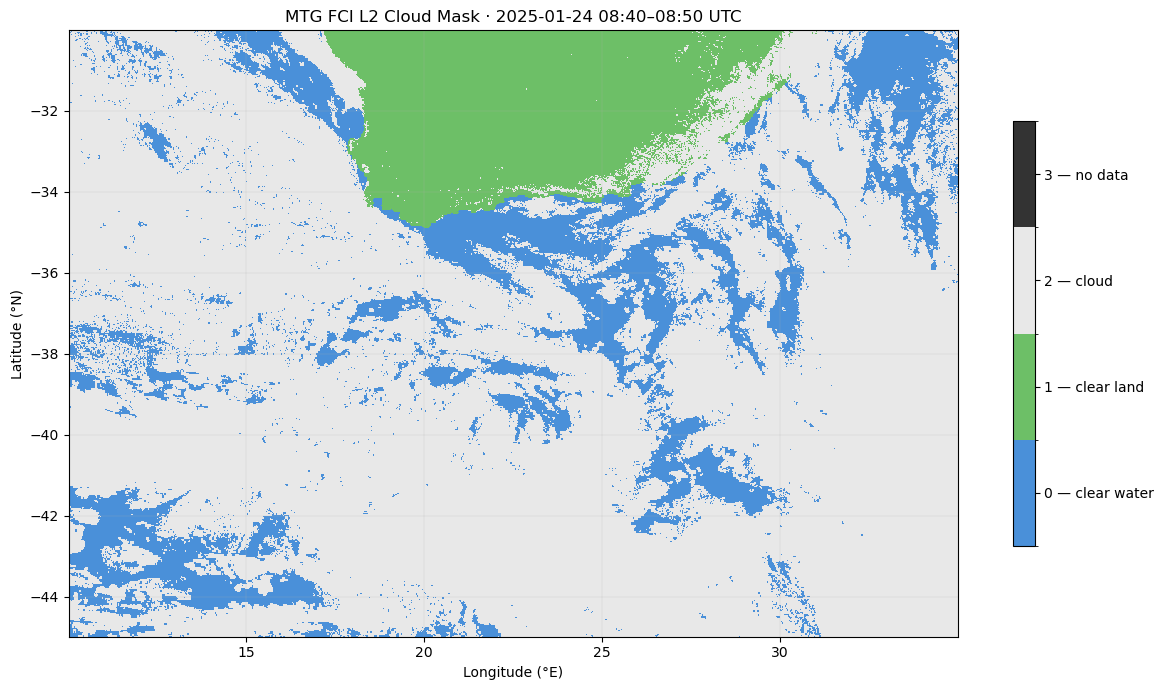

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import xarray as xr

ds = xr.open_dataset(r"D:\EUMETSAT_data\processed_goflow_inputs\10E-35E_45S-30S\202603280000-202603312250_FCI-ir_105_0p02deg.nc")

# CLM colour map: 0=clear water, 1=clear land, 2=cloud, 3=no data
cmap = mcolors.ListedColormap(['#4A90D9', '#6DBF67', '#E8E8E8', '#333333'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(
    ds['cloud_mask'].values,
    origin='upper',
    extent=[
        float(ds.lon.min()), float(ds.lon.max()),
        float(ds.lat.min()), float(ds.lat.max()),
    ],
    cmap=cmap,
    norm=norm,
    interpolation='nearest',
    aspect='auto',
)

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels(['0 — clear water', '1 — clear land', '2 — cloud', '3 — no data'])

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('MTG FCI L2 Cloud Mask · 2025-01-24 08:40–08:50 UTC')
ax.grid(True, linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.show()